# ⚡ EV Charging Network & Grid Load Intelligence

## (1) IMPORTS AND LOAD

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ev_charging_station_usage_grid_load.csv")

In [3]:
df["date_time"] = pd.to_datetime(df["date_time"])

In [4]:
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())

(2800, 10)
   record_id           date_time city_zone  station_type  vehicles_charged  \
0          1 2024-01-01 00:00:00   Central  Supercharger                 9   
1          2 2024-01-01 01:00:00     South          Fast                15   
2          3 2024-01-01 02:00:00      West        Normal                 3   
3          4 2024-01-01 03:00:00      West          Fast                22   
4          5 2024-01-01 04:00:00   Central          Fast                21   

   avg_charging_duration_minutes  energy_dispensed_kwh  grid_load_mw  \
0                          101.6                238.64        179.28   
1                           23.5                129.50        198.56   
2                          104.7                 65.67        134.21   
3                          108.6                303.83         76.49   
4                           78.6                156.32        256.73   

   renewable_energy_used_percent peak_load_risk  
0                           59.1     

In [5]:
df.head()

,record_id,date_time,city_zone,station_type,vehicles_charged,avg_charging_duration_minutes,energy_dispensed_kwh,grid_load_mw,renewable_energy_used_percent,peak_load_risk
0,1,2024-01-01 00:00:00,Central,Supercharger,9,101.6,238.64,179.28,59.1,Medium
1,2,2024-01-01 01:00:00,South,Fast,15,23.5,129.50,198.56,73.6,Low
2,3,2024-01-01 02:00:00,West,Normal,3,104.7,65.67,134.21,63.7,Low
3,4,2024-01-01 03:00:00,West,Fast,22,108.6,303.83,76.49,17.0,Medium
4,5,2024-01-01 04:00:00,Central,Fast,21,78.6,156.32,256.73,17.9,Low


## (2) DATA QUALITY

In [6]:
print(df.info())
print("\nNulls:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nPeak risk values:", df["peak_load_risk"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   record_id                      2800 non-null   int64         
 1   date_time                      2800 non-null   datetime64[ns]
 2   city_zone                      2800 non-null   object        
 3   station_type                   2800 non-null   object        
 4   vehicles_charged               2800 non-null   int64         
 5   avg_charging_duration_minutes  2800 non-null   float64       
 6   energy_dispensed_kwh           2800 non-null   float64       
 7   grid_load_mw                   2800 non-null   float64       
 8   renewable_energy_used_percent  2800 non-null   float64       
 9   peak_load_risk                 2800 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 218.9+ KB
None



## (3) FEATURE ENGINEERING

In [7]:
df["hour"] = df["date_time"].dt.hour
df["day_name"] = df["date_time"].dt.day_name()
df["month"] = df["date_time"].dt.month_name()
df["date"] = df["date_time"].dt.date
df["is_weekend"] = df["day_name"].isin(["Saturday", "Sunday"]).astype(int)

df["energy_per_vehicle"] = np.where(
    df["vehicles_charged"] > 0,
    df["energy_dispensed_kwh"] / df["vehicles_charged"],
    np.nan
)

# simple demand score proxy (normalize and combine)
df["veh_z"] = (df["vehicles_charged"] - df["vehicles_charged"].mean()) / df["vehicles_charged"].std()
df["energy_z"] = (df["energy_dispensed_kwh"] - df["energy_dispensed_kwh"].mean()) / df["energy_dispensed_kwh"].std()
df["demand_score"] = 0.6*df["veh_z"] + 0.4*df["energy_z"]

df.head()

,record_id,date_time,city_zone,station_type,vehicles_charged,avg_charging_duration_minutes,energy_dispensed_kwh,grid_load_mw,renewable_energy_used_percent,peak_load_risk,hour,day_name,month,date,is_weekend,energy_per_vehicle,veh_z,energy_z,demand_score
0,1,2024-01-01 00:00:00,Central,Supercharger,9,101.6,238.64,179.28,59.1,Medium,0,Monday,January,2024-01-01,0,26.515556,-0.502784,0.604275,-0.059961
1,2,2024-01-01 01:00:00,South,Fast,15,23.5,129.50,198.56,73.6,Low,1,Monday,January,2024-01-01,0,8.633333,0.362309,-0.498344,0.018048
2,3,2024-01-01 02:00:00,West,Normal,3,104.7,65.67,134.21,63.7,Low,2,Monday,January,2024-01-01,0,21.890000,-1.367878,-1.143205,-1.278009
3,4,2024-01-01 03:00:00,West,Fast,22,108.6,303.83,76.49,17.0,Medium,3,Monday,January,2024-01-01,0,13.810455,1.371586,1.262876,1.328102
4,5,2024-01-01 04:00:00,Central,Fast,21,78.6,156.32,256.73,17.9,Low,4,Monday,January,2024-01-01,0,7.443810,1.227403,-0.227387,0.645487


## (4) EDA - Zone Demand

In [8]:
zone_summary = df.groupby("city_zone", as_index=False).agg(
    total_vehicles=("vehicles_charged", "sum"),
    total_energy_kwh=("energy_dispensed_kwh", "sum"),
    avg_grid_load_mw=("grid_load_mw", "mean"),
    avg_renewable_pct=("renewable_energy_used_percent", "mean"),
    avg_energy_per_vehicle=("energy_per_vehicle", "mean")
).sort_values("total_vehicles", ascending=False)

zone_summary

,city_zone,total_vehicles,total_energy_kwh,avg_grid_load_mw,avg_renewable_pct,avg_energy_per_vehicle
2,North,7551,106516.40,276.220221,45.310866,25.055152
3,South,7000,100701.33,285.093678,44.605954,28.134592
1,East,6983,103640.23,268.301472,44.001596,31.264275
0,Central,6804,93007.45,270.933245,44.558302,26.184894
4,West,6626,96851.16,280.988242,46.158608,28.491852


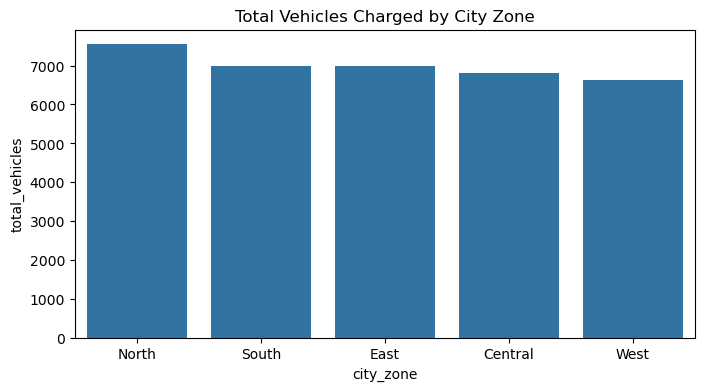

In [9]:
plt.figure(figsize=(8,4))
sns.barplot(data=zone_summary, x="city_zone", y="total_vehicles")
plt.title("Total Vehicles Charged by City Zone")
plt.show()

## (5) EDA - HOURLY TREND

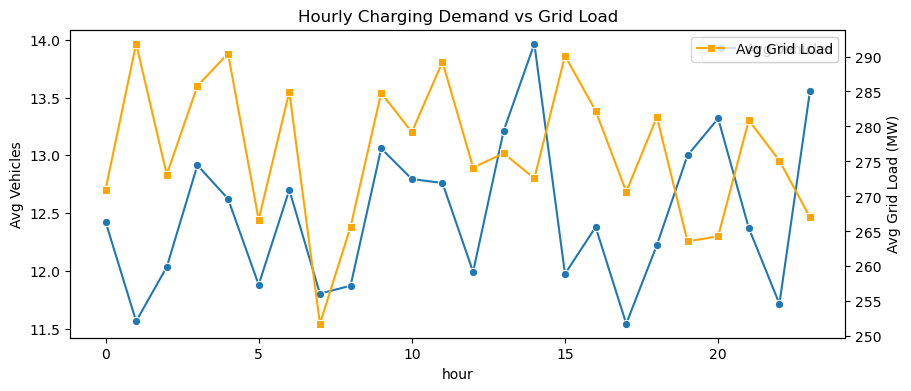

In [10]:
hourly = df.groupby("hour", as_index=False).agg(
    avg_vehicles=("vehicles_charged","mean"),
    avg_grid_load=("grid_load_mw","mean")
)

fig, ax1 = plt.subplots(figsize=(10,4))
sns.lineplot(data=hourly, x="hour", y="avg_vehicles", marker="o", ax=ax1, label="Avg Vehicles")
ax1.set_ylabel("Avg Vehicles")

ax2 = ax1.twinx()
sns.lineplot(data=hourly, x="hour", y="avg_grid_load", marker="s", color="orange", ax=ax2, label="Avg Grid Load")
ax2.set_ylabel("Avg Grid Load (MW)")
plt.title("Hourly Charging Demand vs Grid Load")
plt.show()

## (6)  EDA - STATION TYPE PERFORMANCE

In [11]:
station_summary = df.groupby("station_type", as_index=False).agg(
    total_vehicles=("vehicles_charged","sum"),
    avg_duration=("avg_charging_duration_minutes","mean"),
    avg_energy=("energy_dispensed_kwh","mean"),
    avg_grid_load=("grid_load_mw","mean")
).sort_values("total_vehicles", ascending=False)

station_summary

,station_type,total_vehicles,avg_duration,avg_energy,avg_grid_load
1,Normal,14325,67.447725,179.852828,274.174211
0,Fast,13940,67.584131,176.002394,276.090248
2,Supercharger,6699,66.864610,182.524229,281.378113


## (7) EDA - RISK AND RENEWABLES

In [12]:
risk_summary = df.groupby("peak_load_risk", as_index=False).agg(
    avg_grid_load=("grid_load_mw","mean"),
    avg_renewable=("renewable_energy_used_percent","mean"),
    avg_vehicles=("vehicles_charged","mean")
)

risk_summary

,peak_load_risk,avg_grid_load,avg_renewable,avg_vehicles
0,High,275.546855,43.967138,12.530035
1,Low,275.403283,44.934615,12.470085
2,Medium,278.545422,45.566145,12.486747


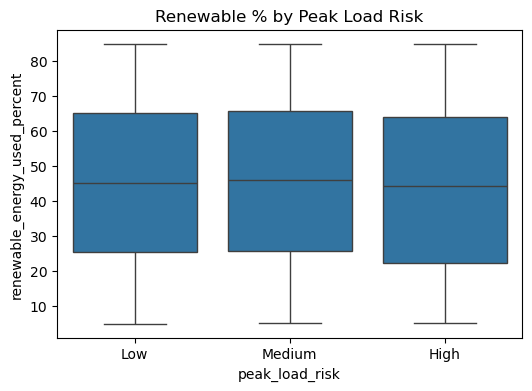

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="peak_load_risk", y="renewable_energy_used_percent", order=["Low","Medium","High"])
plt.title("Renewable % by Peak Load Risk")
plt.show()

## (8) GAP/PRIORITY SCORING PER ZONE

In [14]:
zone_kpi = df.groupby("city_zone", as_index=False).agg(
    vehicles=("vehicles_charged","sum"),
    avg_grid=("grid_load_mw","mean"),
    avg_renewable=("renewable_energy_used_percent","mean"),
    high_risk_share=("peak_load_risk", lambda x: (x=="High").mean())
)

for c in ["vehicles","avg_grid","avg_renewable","high_risk_share"]:
    zone_kpi[c+"_norm"] = (zone_kpi[c] - zone_kpi[c].min())/(zone_kpi[c].max()-zone_kpi[c].min())

zone_kpi["priority_score"] = (
    0.35*zone_kpi["vehicles_norm"] +
    0.30*zone_kpi["high_risk_share_norm"] +
    0.25*zone_kpi["avg_grid_norm"] -
    0.10*zone_kpi["avg_renewable_norm"]
)

zone_kpi.sort_values("priority_score", ascending=False)

,city_zone,vehicles,avg_grid,avg_renewable,high_risk_share,vehicles_norm,avg_grid_norm,avg_renewable_norm,high_risk_share_norm,priority_score
3,South,7000,285.093678,44.605954,0.204904,0.404324,1.000000,0.280183,0.641251,0.555871
2,North,7551,276.220221,45.310866,0.176570,1.000000,0.471573,0.606983,0.000000,0.407195
0,Central,6804,270.933245,44.558302,0.220755,0.192432,0.156726,0.258091,1.000000,0.380724
4,West,6626,280.988242,46.158608,0.210623,0.000000,0.755515,1.000000,0.770687,0.320085
1,East,6983,268.301472,44.001596,0.200355,0.385946,0.000000,0.000000,0.538295,0.296569


In [15]:
df.to_csv("processed_ev_data.csv", index=False)
zone_kpi.to_csv("zone_priority_score.csv", index=False)
print("Exported: processed_ev_data.csv, zone_priority_score.csv")

Exported: processed_ev_data.csv, zone_priority_score.csv
